In [ ]:
!pip -q install altair openpyxl

import os
import pandas as pd
import numpy as np
import altair as alt
from IPython.display import display

alt.data_transformers.disable_max_rows()

file_name = "/content/drive/MyDrive/EMM_EPM0_PTE_SCA_DPGm.xls" # Updated file path

# The following block is removed as file_name is now explicitly set to an existing file.
# if not os.path.exists(file_name):
#     xlsx_files = [f for f in os.listdir() if f.endswith(".xlsx")]
#     file_name = xlsx_files[0]

sp = pd.read_excel(file_name, sheet_name="Data 1")
gas = pd.read_excel(file_name, sheet_name="Data 1")

sp["Date"] = pd.to_datetime(sp["Date"])

sp["Close"] = (
    sp["Close"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("$", "", regex=False)
)

sp["Volume"] = (
    sp["Volume"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("$", "", regex=False)
)

sp["Close"] = pd.to_numeric(sp["Close"], errors="coerce")
sp["Volume"] = pd.to_numeric(sp["Volume"], errors="coerce")

gas = gas.rename(columns={gas.columns[1]: "Gas_Price"})

gas["Gas_Price"] = (
    gas["Gas_Price"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("$", "", regex=False)
)

gas["Gas_Price"] = pd.to_numeric(gas["Gas_Price"], errors="coerce")
gas["Year"] = pd.to_numeric(gas["Year"], errors="coerce")

sp = sp.dropna(subset=["Date", "Close"])
gas = gas.dropna(subset=["Year", "Gas_Price"])

sp = sp.sort_values("Date")
gas = gas.sort_values("Year")

sp["Year"] = sp["Date"].dt.year
sp["Daily_Return"] = sp["Close"].pct_change()

sp_yearly = sp.groupby("Year").agg(
    SP_Start=("Close", "first"),
    SP_End=("Close", "last"),
    SP_Avg=("Close", "mean"),
    Volume_Avg=("Volume", "mean"),
    SP_Volatility=("Daily_Return", "std")
).reset_index()

sp_yearly["SP_Return"] = (sp_yearly["SP_End"] / sp_yearly["SP_Start"] - 1) * 100
sp_yearly["Volume_Change"] = sp_yearly["Volume_Avg"].pct_change() * 100
sp_yearly["SP_Volatility"] = sp_yearly["SP_Volatility"] * 100

gas["Gas_Change"] = gas["Gas_Price"].pct_change() * 100

df = pd.merge(sp_yearly, gas, on="Year", how="inner")
df = df.dropna()

df["Date"] = pd.to_datetime(df["Year"].astype(int).astype(str) + "-01-01")

df["SP_Index"] = df["SP_Avg"] / df["SP_Avg"].iloc[0] * 100
df["Gas_Index"] = df["Gas_Price"] / df["Gas_Price"].iloc[0] * 100

def event_group(year):
    if year in [2008, 2009]:
        return "Financial Crisis"
    elif year in [2020, 2021]:
        return "COVID"
    elif year == 2022:
        return "Energy Shock"
    elif year in [2023, 2024, 2025]:
        return "Recent Conflict"
    else:
        return "Normal Year"

df["Event"] = df["Year"].apply(event_group)

df["Gas_Direction"] = np.where(df["Gas_Change"] >= 0, "Gas Up", "Gas Down")
df["SP_Direction"] = np.where(df["SP_Return"] >= 0, "S&P Up", "S&P Down")
df["Pattern"] = df["SP_Direction"] + " / " + df["Gas_Direction"]

long_index = df.melt(
    id_vars=["Year", "Date", "Event"],
    value_vars=["SP_Index", "Gas_Index"],
    var_name="Type",
    value_name="Index_Value"
)

long_index["Type"] = long_index["Type"].replace({
    "SP_Index": "S&P 500",
    "Gas_Index": "Gas Prices"
})

long_change = df.melt(
    id_vars=["Year", "Date", "Event"],
    value_vars=["SP_Return", "Gas_Change"],
    var_name="Type",
    value_name="Percent_Change"
)

long_change["Type"] = long_change["Type"].replace({
    "SP_Return": "S&P 500 Return",
    "Gas_Change": "Gas Price Change"
})

!pip -q install vl-convert-python
from IPython.display import Image
display(df.head())

KeyError: 'Date'

In [ ]:
print(sp.columns)
print(gas.columns)

Index(['Back to Contents', 'Data 1: California All Grades All Formulations Retail Gasoline Prices (Dollars per Gallon)'], dtype='object')
Index(['Back to Contents', 'Data 1: California All Grades All Formulations Retail Gasoline Prices (Dollars per Gallon)'], dtype='object')


In [ ]:
xls = pd.ExcelFile(file_name)
print(xls.sheet_names)

['Contents', 'Data 1']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip -q install vl-convert-python
from IPython.display import Image

chart1 = alt.Chart(long_index).mark_line(point=True).encode(
    x=alt.X("Year:O", title="Year"),
    y=alt.Y("Index_Value:Q", title="Index Value"),
    color=alt.Color("Type:N", title="Series"),
    tooltip=[
        "Year:O",
        "Type:N",
        alt.Tooltip("Index_Value:Q", format=".1f"),
        "Event:N"
    ]
).properties(
    title="Indexed S&P 500 vs Gas Prices",
    width=800,
    height=400
)

chart1.save("chart1.png")
display(Image("chart1.png"))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 41.8 MB/s eta 0:00:00


NameError: name 'long_index' is not defined

In [ ]:
from IPython.display import Image

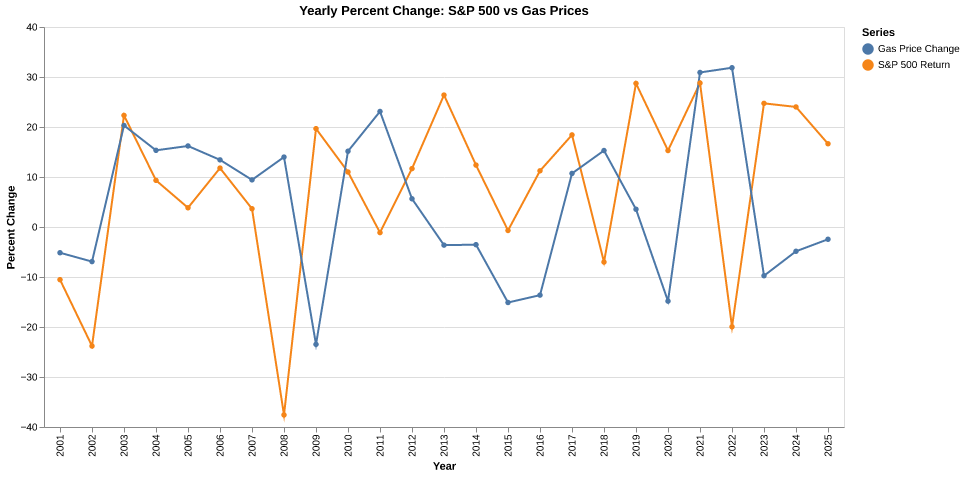

In [ ]:
chart2 = alt.Chart(long_change).mark_line(point=True).encode(
    x=alt.X("Year:O", title="Year"),
    y=alt.Y("Percent_Change:Q", title="Percent Change"),
    color=alt.Color("Type:N", title="Series"),
    tooltip=[
        "Year:O",
        "Type:N",
        alt.Tooltip("Percent_Change:Q", format=".1f"),
        "Event:N"
    ]
).properties(
    title="Yearly Percent Change: S&P 500 vs Gas Prices",
    width=800,
    height=400
)

chart2.save("chart2.png")
display(Image("chart2.png"))

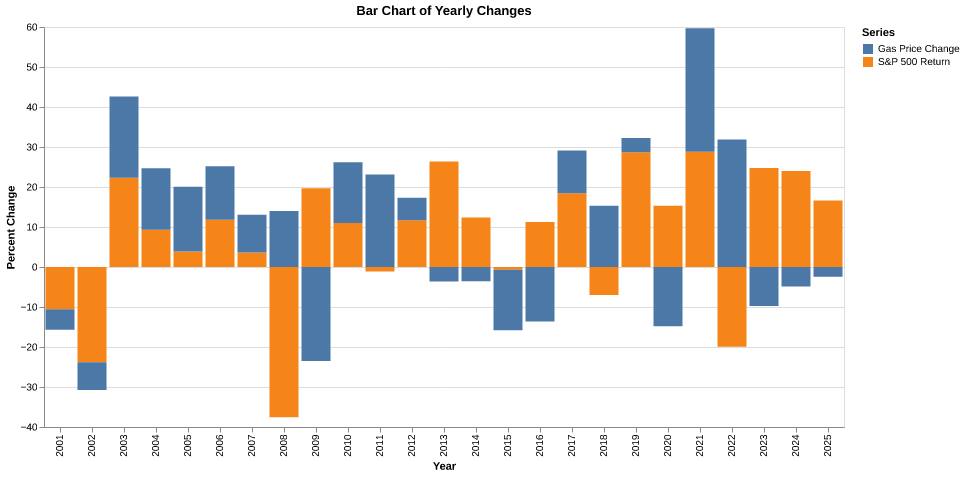

In [ ]:
chart3 = alt.Chart(long_change).mark_bar().encode(
    x=alt.X("Year:O", title="Year"),
    y=alt.Y("Percent_Change:Q", title="Percent Change"),
    color=alt.Color("Type:N", title="Series"),
    tooltip=[
        "Year:O",
        "Type:N",
        alt.Tooltip("Percent_Change:Q", format=".1f"),
        "Event:N"
    ]
).properties(
    title="Bar Chart of Yearly Changes",
    width=800,
    height=400
)

chart3.save("chart3.png")
display(Image("chart3.png"))

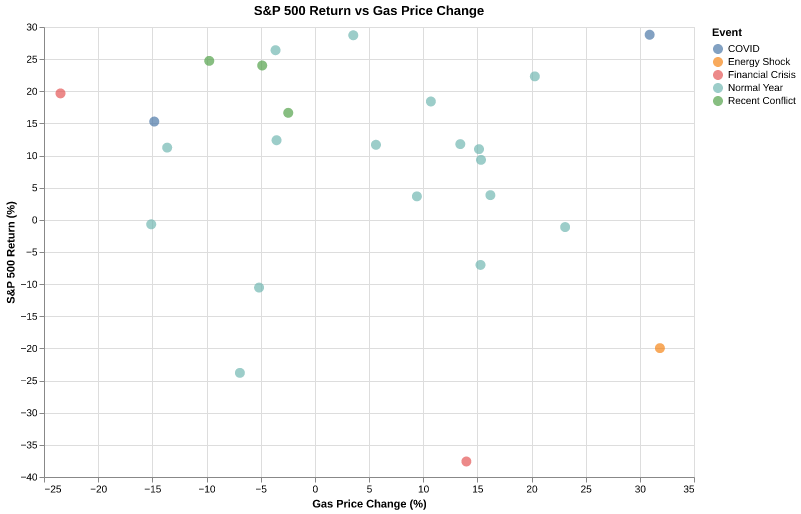

In [ ]:
chart4 = alt.Chart(df).mark_circle(size=100).encode(
    x=alt.X("Gas_Change:Q", title="Gas Price Change (%)"),
    y=alt.Y("SP_Return:Q", title="S&P 500 Return (%)"),
    color=alt.Color("Event:N", title="Event"),
    tooltip=[
        "Year:O",
        "Event:N",
        alt.Tooltip("Gas_Change:Q", format=".1f"),
        alt.Tooltip("SP_Return:Q", format=".1f")
    ]
).properties(
    title="S&P 500 Return vs Gas Price Change",
    width=650,
    height=450
)

chart4.save("chart4.png")
display(Image("chart4.png"))

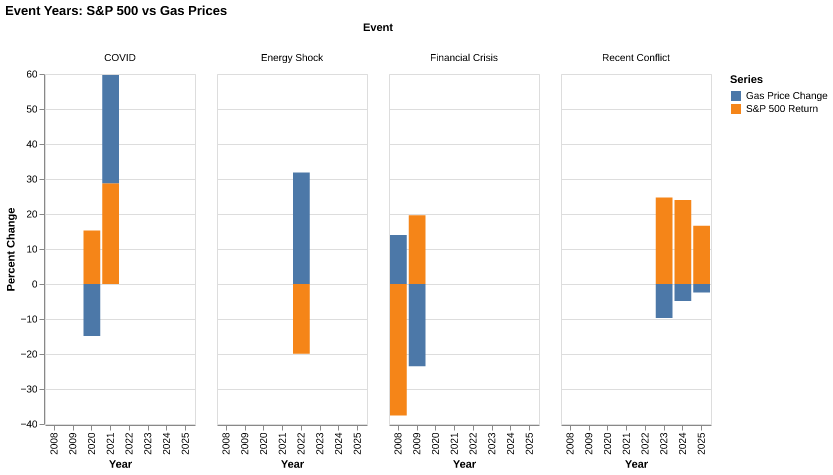

In [ ]:
event_df = df[df["Event"] != "Normal Year"]

event_long = event_df.melt(
    id_vars=["Year", "Event"],
    value_vars=["SP_Return", "Gas_Change"],
    var_name="Type",
    value_name="Percent_Change"
)

event_long["Type"] = event_long["Type"].replace({
    "SP_Return": "S&P 500 Return",
    "Gas_Change": "Gas Price Change"
})

chart5 = alt.Chart(event_long).mark_bar().encode(
    x=alt.X("Year:O", title="Year"),
    y=alt.Y("Percent_Change:Q", title="Percent Change"),
    color=alt.Color("Type:N", title="Series"),
    column=alt.Column("Event:N", title="Event"),
    tooltip=[
        "Year:O",
        "Event:N",
        "Type:N",
        alt.Tooltip("Percent_Change:Q", format=".1f")
    ]
).properties(
    title="Event Years: S&P 500 vs Gas Prices",
    width=150,
    height=350
)

chart5.save("chart5.png")
display(Image("chart5.png"))

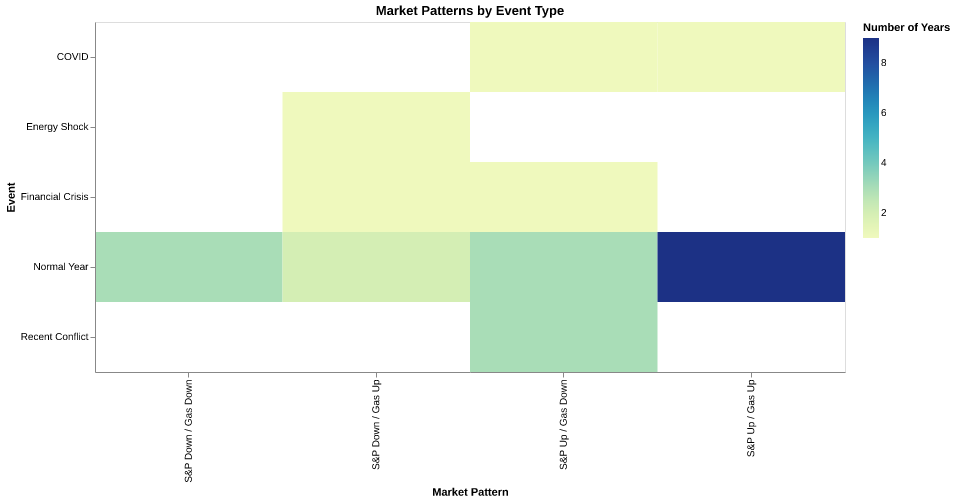

In [ ]:
pattern_counts = df.groupby(["Event", "Pattern"]).size().reset_index(name="Count")

chart6 = alt.Chart(pattern_counts).mark_rect().encode(
    x=alt.X("Pattern:N", title="Market Pattern"),
    y=alt.Y("Event:N", title="Event"),
    color=alt.Color("Count:Q", title="Number of Years"),
    tooltip=[
        "Event:N",
        "Pattern:N",
        "Count:Q"
    ]
).properties(
    title="Market Patterns by Event Type",
    width=750,
    height=350
)

chart6.save("chart6.png")
display(Image("chart6.png"))

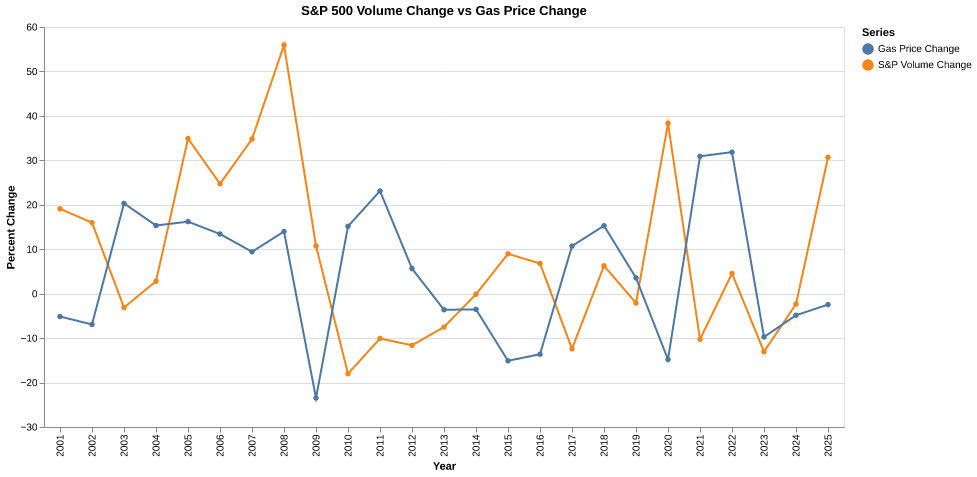

In [ ]:
volume_long = df.melt(
    id_vars=["Year", "Date", "Event"],
    value_vars=["Volume_Change", "Gas_Change"],
    var_name="Type",
    value_name="Percent_Change"
)

volume_long["Type"] = volume_long["Type"].replace({
    "Volume_Change": "S&P Volume Change",
    "Gas_Change": "Gas Price Change"
})

chart7 = alt.Chart(volume_long).mark_line(point=True).encode(
    x=alt.X("Year:O", title="Year"),
    y=alt.Y("Percent_Change:Q", title="Percent Change"),
    color=alt.Color("Type:N", title="Series"),
    tooltip=[
        "Year:O",
        "Type:N",
        alt.Tooltip("Percent_Change:Q", format=".1f"),
        "Event:N"
    ]
).properties(
    title="S&P 500 Volume Change vs Gas Price Change",
    width=800,
    height=400
)

chart7.save("chart7.png")
display(Image("chart7.png"))

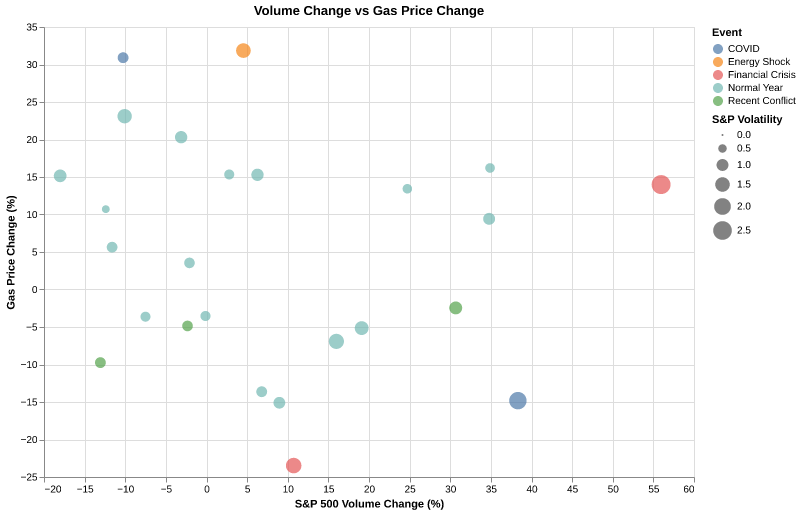

In [ ]:
chart8 = alt.Chart(df).mark_circle(size=100).encode(
    x=alt.X("Volume_Change:Q", title="S&P 500 Volume Change (%)"),
    y=alt.Y("Gas_Change:Q", title="Gas Price Change (%)"),
    color=alt.Color("Event:N", title="Event"),
    size=alt.Size("SP_Volatility:Q", title="S&P Volatility"),
    tooltip=[
        "Year:O",
        "Event:N",
        alt.Tooltip("Volume_Change:Q", format=".1f"),
        alt.Tooltip("Gas_Change:Q", format=".1f"),
        alt.Tooltip("SP_Volatility:Q", format=".2f")
    ]
).properties(
    title="Volume Change vs Gas Price Change",
    width=650,
    height=450
)

chart8.save("chart8.png")
display(Image("chart8.png"))

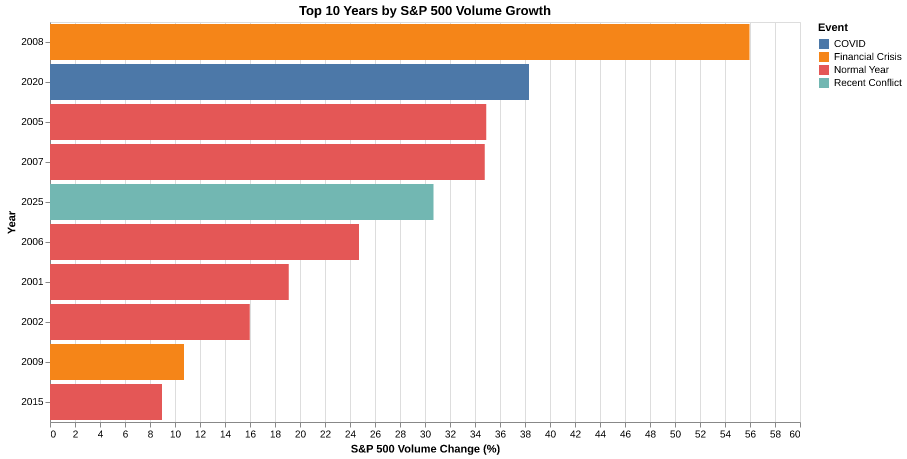

In [ ]:
top_volume = df.sort_values("Volume_Change", ascending=False).head(10)

chart9 = alt.Chart(top_volume).mark_bar().encode(
    x=alt.X("Volume_Change:Q", title="S&P 500 Volume Change (%)"),
    y=alt.Y("Year:O", sort="-x", title="Year"),
    color=alt.Color("Event:N", title="Event"),
    tooltip=[
        "Year:O",
        "Event:N",
        alt.Tooltip("Volume_Change:Q", format=".1f"),
        alt.Tooltip("Gas_Change:Q", format=".1f"),
        alt.Tooltip("SP_Return:Q", format=".1f")
    ]
).properties(
    title="Top 10 Years by S&P 500 Volume Growth",
    width=750,
    height=400
)

chart9.save("chart9.png")
display(Image("chart9.png"))

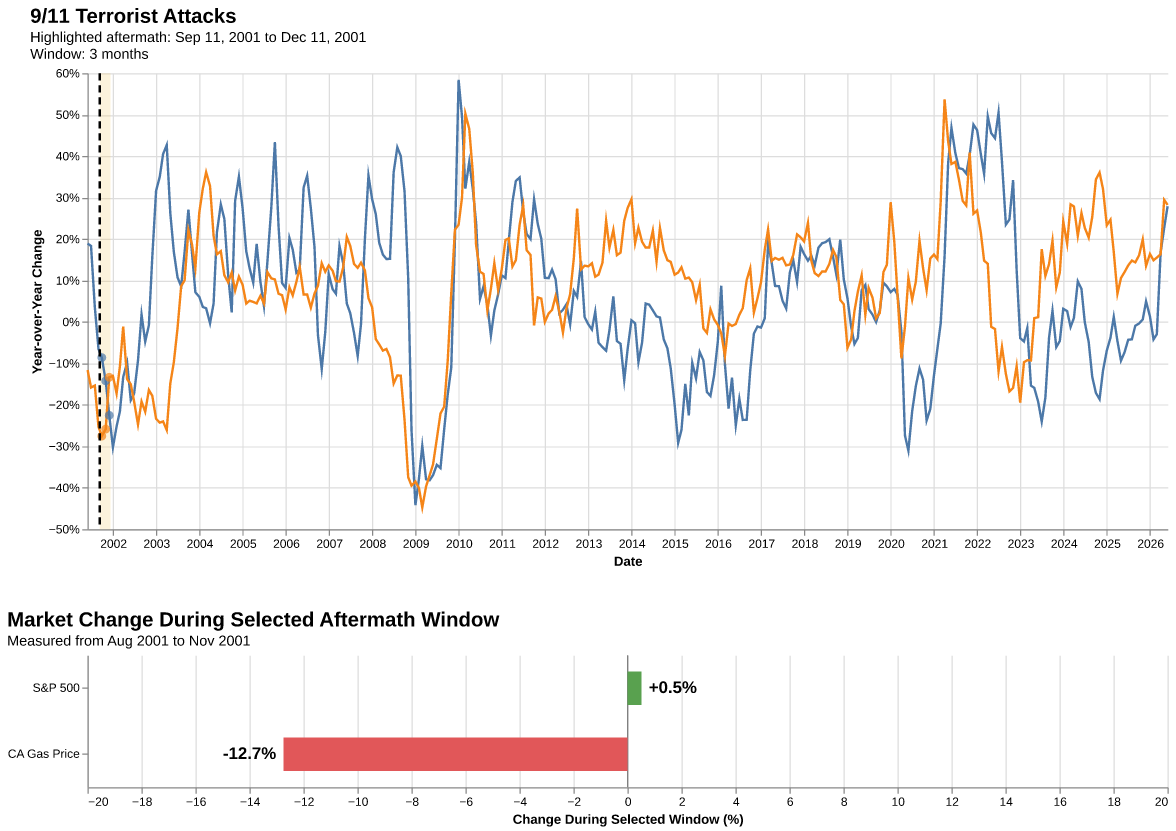

In [ ]:
import os
import pandas as pd
import altair as alt
import ipywidgets as widgets

from IPython.display import display, Image, clear_output

try:
    from google.colab import output
    output.enable_custom_widget_manager()
except:
    pass

alt.data_transformers.disable_max_rows()

# Define the base path for Google Drive files
drive_path = "/content/drive/MyDrive/"

market_file_name = "SP500_GasPrices_Tableau_v3.xlsx"
events_file_name = "Major_Global_Events_2001_Present.xlsx"

market_file = os.path.join(drive_path, market_file_name)
events_file = os.path.join(drive_path, events_file_name)

# Check if the market data file exists
if not os.path.exists(market_file):
    print(f"Error: No market data file ('{market_file_name}') found at '{market_file}'.")
    print("Please ensure the file is uploaded to your Colab environment or provide the correct path.")
    raise FileNotFoundError("Market data file not found.")

# Check if the events data file exists
if not os.path.exists(events_file):
    print(f"Error: No event data file ('{events_file_name}') found at '{events_file}'.")
    print("Please ensure the file is uploaded to your Colab environment or provide the correct path.")
    raise FileNotFoundError("Event data file not found.")


monthly = pd.read_excel(
    market_file,
    sheet_name="Monthly_Data"
)

events = pd.read_excel(
    events_file,
    sheet_name="Global Events"
)


monthly["Date"] = pd.to_datetime(monthly["Date"])
events["Start Date"] = pd.to_datetime(events["Start Date"])


monthly = monthly.dropna(
    subset=[
        "Date",
        "S&P 500 Close",
        "CA Gas Price ($/gal)",
        "S&P 500 YoY Change %",
        "Gas Price YoY Change %"
    ]
)

events = events.dropna(
    subset=[
        "Event Name",
        "Start Date"
    ]
)


monthly = monthly.sort_values("Date")
events = events.sort_values("Start Date")


line_data = monthly.melt(
    id_vars=["Date"],
    value_vars=[
        "Gas Price YoY Change %",
        "S&P 500 YoY Change %"
    ],
    var_name="Market",
    value_name="YoY Change"
)

event_options = []

for i, row in events.iterrows():

    label = (
        row["Start Date"].strftime("%Y-%m-%d")
        + " — "
        + row["Event Name"]
    )

    event_options.append(
        (label, row["Event Name"])
    )


event_selector = widgets.Select(
    options=event_options,
    value=event_options[0][1],
    rows=18,
    description="",
    layout=widgets.Layout(
        width="430px",
        height="500px"
    )
)


window_selector = widgets.ToggleButtons(
    options=[
        ("3 months", 3),
        ("6 months", 6),
        ("12 months", 12)
    ],
    value=6,
    description="Window:"
)


chart_output = widgets.Output()


def make_event_chart(event_name, window_months):

    selected_event = events[
        events["Event Name"] == event_name
    ].iloc[0]

    event_start = selected_event["Start Date"]

    target_end = event_start + pd.DateOffset(
        months=window_months
    )

    highlight_end = min(
        target_end,
        monthly["Date"].max()
    )


    start_rows = monthly[
        monthly["Date"] <= event_start
    ]

    if len(start_rows) > 0:
        start_row = start_rows.iloc[-1]
    else:
        start_row = monthly.iloc[0]


    end_rows = monthly[
        monthly["Date"] <= target_end
    ]

    if len(end_rows) > 0:
        end_row = end_rows.iloc[-1]
    else:
        end_row = monthly.iloc[-1]


    sp_change = (
        end_row["S&P 500 Close"]
        / start_row["S&P 500 Close"]
        - 1
    ) * 100


    gas_change = (
        end_row["CA Gas Price ($/gal)"]
        / start_row["CA Gas Price ($/gal)"]
        - 1
    ) * 100


    band_data = pd.DataFrame({
        "Start": [event_start],
        "End": [highlight_end]
    })


    start_line_data = pd.DataFrame({
        "Event Start": [event_start]
    })


    selected_points = line_data[
        (line_data["Date"] >= event_start)
        &
        (line_data["Date"] <= highlight_end)
    ]


    highlight_band = alt.Chart(
        band_data
    ).mark_rect(
        color="#F2C14E",
        opacity=0.20
    ).encode(
        x="Start:T",
        x2="End:T"
    )


    lines = alt.Chart(
        line_data
    ).mark_line(
        strokeWidth=2
    ).encode(

        x=alt.X(
            "Date:T",
            title="Date"
        ),

        y=alt.Y(
            "YoY Change:Q",
            title="Year-over-Year Change",
            axis=alt.Axis(format=".0%")
        ),

        color=alt.Color(
            "Market:N",
            title="Market",
            scale=alt.Scale(
                domain=[
                    "Gas Price YoY Change %",
                    "S&P 500 YoY Change %"
                ],
                range=[
                    "#4C78A8",
                    "#F58518"
                ]
            )
        ),

        tooltip=[
            alt.Tooltip(
                "Date:T",
                title="Month",
                format="%b %Y"
            ),

            alt.Tooltip(
                "Market:N",
                title="Market"
            ),

            alt.Tooltip(
                "YoY Change:Q",
                title="YoY Change",
                format=".1%"
            )
        ]
    )


    points = alt.Chart(
        selected_points
    ).mark_circle(
        size=55
    ).encode(

        x="Date:T",

        y="YoY Change:Q",

        color=alt.Color(
            "Market:N",
            scale=alt.Scale(
                domain=[
                    "Gas Price YoY Change %",
                    "S&P 500 YoY Change %"
                ],
                range=[
                    "#4C78A8",
                    "#F58518"
                ]
            ),
            legend=None
        )
    )

event_options = []

for i, row in events.iterrows():
    label = (
        row["Start Date"].strftime("%Y-%m-%d")
        + " — "
        + row["Event Name"]
    )

    event_options.append(
        (label, row["Event Name"])
    )


event_selector = widgets.Select(
    options=event_options,
    value=event_options[0][1],
    rows=10,
    description="",
    layout=widgets.Layout(
        width="700px",
        height="260px"
    )
)


window_selector = widgets.ToggleButtons(
    options=[
        ("3 months", 3),
        ("6 months", 6),
        ("12 months", 12)
    ],
    value=6,
    description="",
    layout=widgets.Layout(
        width="300px"
    )
)


chart_output = widgets.Output(
    layout=widgets.Layout(
        width="100%"
    )
)


def make_event_chart(event_name, window_months):

    selected_event = events[
        events["Event Name"] == event_name
    ].iloc[0]

    event_start = selected_event["Start Date"]

    target_end = event_start + pd.DateOffset(
        months=window_months
    )

    highlight_end = min(
        target_end,
        monthly["Date"].max()
    )


    start_rows = monthly[
        monthly["Date"] <= event_start
    ]

    if len(start_rows) > 0:
        start_row = start_rows.iloc[-1]
    else:
        start_row = monthly.iloc[0]


    end_rows = monthly[
        monthly["Date"] <= target_end
    ]

    if len(end_rows) > 0:
        end_row = end_rows.iloc[-1]
    else:
        end_row = monthly.iloc[-1]


    sp_change = (
        end_row["S&P 500 Close"]
        / start_row["S&P 500 Close"]
        - 1
    ) * 100


    gas_change = (
        end_row["CA Gas Price ($/gal)"]
        / start_row["CA Gas Price ($/gal)"]
        - 1
    ) * 100


    band_data = pd.DataFrame({
        "Start": [event_start],
        "End": [highlight_end]
    })


    start_line_data = pd.DataFrame({
        "Event Start": [event_start]
    })


    selected_points = line_data[
        (line_data["Date"] >= event_start)
        &
        (line_data["Date"] <= highlight_end)
    ]


    highlight_band = alt.Chart(
        band_data
    ).mark_rect(
        color="#F2C14E",
        opacity=0.20
    ).encode(
        x="Start:T",
        x2="End:T"
    )


    lines = alt.Chart(
        line_data
    ).mark_line(
        strokeWidth=2
    ).encode(

        x=alt.X(
            "Date:T",
            title="Date"
        ),

        y=alt.Y(
            "YoY Change:Q",
            title="Year-over-Year Change",
            axis=alt.Axis(format=".0%")
        ),

        color=alt.Color(
            "Market:N",
            title="Market",
            scale=alt.Scale(
                domain=[
                    "Gas Price YoY Change %",
                    "S&P 500 YoY Change %"
                ],
                range=[
                    "#4C78A8",
                    "#F58518"
                ]
            )
        ),

        tooltip=[
            alt.Tooltip(
                "Date:T",
                title="Month",
                format="%b %Y"
            ),

            alt.Tooltip(
                "Market:N",
                title="Market"
            ),

            alt.Tooltip(
                "YoY Change:Q",
                title="YoY Change",
                format=".1%"
            )
        ]
    )


    points = alt.Chart(
        selected_points
    ).mark_circle(
        size=55
    ).encode(

        x="Date:T",

        y="YoY Change:Q",

        color=alt.Color(
            "Market:N",
            scale=alt.Scale(
                domain=[
                    "Gas Price YoY Change %",
                    "S&P 500 YoY Change %"
                ],
                range=[
                    "#4C78A8",
                    "#F58518"
                ]
            ),
            legend=None
        )
    )


    event_rule = alt.Chart(
        start_line_data
    ).mark_rule(
        color="black",
        strokeDash=[6, 4],
        strokeWidth=2
    ).encode(
        x="Event Start:T"
    )


    main_chart = (
        highlight_band
        + lines
        + points
        + event_rule
    ).properties(

        title=alt.TitleParams(
            text=event_name,
            subtitle=[
                "Highlighted aftermath: "
                + event_start.strftime("%b %d, %Y")
                + " to "
                + highlight_end.strftime("%b %d, %Y"),

                "Window: "
                + str(window_months)
                + " months"
            ],
            anchor="start"
        ),

        width=900,
        height=380
    )


    summary_data = pd.DataFrame({
        "Market": [
            "S&P 500",
            "CA Gas Price"
        ],

        "Change": [
            sp_change,
            gas_change
        ]
    })


    summary_data["Label"] = summary_data["Change"].map(
        lambda x: f"{x:+.1f}%"
    )


    max_abs_change = max(
        abs(summary_data["Change"]).max(),
        5
    )

    chart_limit = max_abs_change * 1.25


    change_bars = alt.Chart(
        summary_data
    ).mark_bar(
        size=28
    ).encode(

        y=alt.Y(
            "Market:N",
            title=None,
            sort=[
                "S&P 500",
                "CA Gas Price"
            ]
        ),

        x=alt.X(
            "Change:Q",
            title="Change During Selected Window (%)",
            scale=alt.Scale(
                domain=[
                    -chart_limit,
                    chart_limit
                ]
            )
        ),

        color=alt.condition(
            "datum.Change >= 0",
            alt.value("#59A14F"),
            alt.value("#E15759")
        ),

        tooltip=[
            alt.Tooltip(
                "Market:N",
                title="Market"
            ),

            alt.Tooltip(
                "Change:Q",
                title="Change",
                format=".1f"
            )
        ]
    )


    zero_line = alt.Chart(
        pd.DataFrame({
            "Zero": [0]
        })
    ).mark_rule(
        color="gray"
    ).encode(
        x="Zero:Q"
    )


    positive_labels = alt.Chart(
        summary_data
    ).transform_filter(
        "datum.Change >= 0"
    ).mark_text(
        align="left",
        dx=6,
        fontSize=14,
        fontWeight="bold"
    ).encode(

        y=alt.Y(
            "Market:N",
            sort=[
                "S&P 500",
                "CA Gas Price"
            ]
        ),

        x="Change:Q",

        text="Label:N"
    )


    negative_labels = alt.Chart(
        summary_data
    ).transform_filter(
        "datum.Change < 0"
    ).mark_text(
        align="right",
        dx=-6,
        fontSize=14,
        fontWeight="bold"
    ).encode(

        y=alt.Y(
            "Market:N",
            sort=[
                "S&P 500",
                "CA Gas Price"
            ]
        ),

        x="Change:Q",

        text="Label:N"
    )


    change_chart = (
        zero_line
        + change_bars
        + positive_labels
        + negative_labels
    ).properties(

        title=alt.TitleParams(
            text="Market Change During Selected Aftermath Window",
            subtitle=[
                "Measured from "
                + start_row["Date"].strftime("%b %Y")
                + " to "
                + end_row["Date"].strftime("%b %Y")
            ],
            anchor="start"
        ),

        width=900,
        height=110
    )


    final_chart = alt.vconcat(
        main_chart,
        change_chart,
        spacing=35
    ).resolve_scale(
        color="independent"
    ).configure_view(
        stroke=None
    ).configure_title(
        fontSize=17,
        subtitleFontSize=12
    )


    final_chart.save(
        "selected_event_chart.png",
        scale_factor=1.2
    )


    display(
        Image(
            filename="selected_event_chart.png",
            width=1050
        )
    )


def update_chart(change=None):

    with chart_output:

        clear_output(wait=True)

        make_event_chart(
            event_selector.value,
            window_selector.value
        )


event_selector.observe(
    update_chart,
    names="value"
)

window_selector.observe(
    update_chart,
    names="value"
)


event_panel = widgets.VBox([

    widgets.HTML(
        value=
        "<h3 style='margin-bottom:5px;'>Select an Event</h3>"
        "<p style='margin-top:0;'>Scroll through the list and click an event.</p>"
    ),

    event_selector
])


window_panel = widgets.VBox([

    widgets.HTML(
        value=
        "<h3 style='margin-bottom:10px;'>Aftermath Window</h3>"
        "<p>Select how long to track the market after the event.</p>"
    ),

    window_selector
])


controls = widgets.HBox(
    [
        event_panel,
        window_panel
    ],

    layout=widgets.Layout(
        width="100%",
        align_items="flex-start"
    )
)


dashboard = widgets.VBox(
    [
        controls,
        chart_output
    ],

    layout=widgets.Layout(
        width="100%"
    )
)


display(dashboard)

update_chart()